# 1) Imports and Setup

In [7]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import scipy.cluster.hierarchy as sch
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from adjustText import adjust_text

# Get the absolute path to the project root
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
models_path = os.path.join(project_root, 'models')
sys.path.append(models_path)

from DKT.dkt_model import DKT

# 2) Model and Data Imports


In [8]:
# Load the JSON file
with open('dkt_best_config.json', 'r') as f:
    best_config = json.load(f)
skills_file_path = os.path.join(os.getcwd(), '..', '..', 'data', 'preprocessed', 'df_skill_names.csv')
df_skill_names = pd.read_csv(skills_file_path)

num_skills = best_config['model_params']['num_skills']
embedding_dim = best_config['model_params']['embed_dim']


model = DKT(**best_config['model_params'])
model.load_state_dict(torch.load('dkt_full_model.pth', map_location=torch.device('cpu')))
# Set the model to evaluation model
model.eval()


C:\Users\Botond\AppData\Local\Temp\ipykernel_20744\4108343498.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('dkt_full_model.pth', map

DKT(
  (embedding): CustomEmbedding(
    (linear): Linear(in_features=109, out_features=3, bias=False)
  )
  (rnn): LSTM(8, 200, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (out): Linear(in_features=200, out_features=109, bias=True)
  (sigmoid): Sigmoid()
)

In [26]:
# Step 1: Create a mapping for the skill_name to categories
skill_groups = {

    "Data Graphs": [
        'Box and Whisker', 'Circle Graph', 'Histogram as Table or Graph', 'Number Line', 'Scatter Plot', 
        'Stem and Leaf Plot', 'Table', 'Venn Diagram'
    ],

    "Statistics": [
        'Mean', 'Median', 'Mode', 'Range'
    ],

    "Probability": [
        'Probability of Two Distinct Events', 'Probability of a Single Event', 'D.4.8-understanding-concept-of-probabilities'
    ],

    "Basic Operations": [
        'Addition Whole Numbers', 'Division Fractions', 'Estimation', 'Multiplication and Division Positive Decimals', 
        'Addition and Subtraction Integers', 'Addition and Subtraction Positive Decimals', 
        'Multiplication and Division Integers', 'Addition and Subtraction Fractions', 'Order of Operations +,-,/,* () positive reals', 
        'Order of Operations All', 'Conversion of Fraction Decimals Percents', 'Equivalent Fractions', 'Ordering Positive Decimals', 
        'Ordering Fractions', 'Ordering Integers', 'Ordering Real Numbers', 'Rounding',
        'Least Common Multiple', 'Multiplication Fractions', 'Multiplication Whole Numbers',
        'Subtraction Whole Numbers', 'Square Root', 'Computation with Real Numbers'
    ],

    "Percentage Calculations": [
        'Fraction Of', 'Percents', 'Rate', 'Scale Factor', 'Percent Of', 'Percent Discount', 'Finding Percents', 'Proportion',
    ],

    "Algebra": [
        'Algebraic Simplification', 'Algebraic Solving', 'Choose an Equation from Given Information', 
        'Intercept', 'Linear Equations', 'Polynomial Factors', 'Equation Solving Two or Fewer Steps', 
        'Equation Solving More Than Two Steps', 'Solving for a variable', 'Solving Inequalities', 
        'Solving Systems of Linear Equations by Graphing', 'Slope', 'Write Linear Equation from Ordered Pairs',
        'Solving Systems of Linear Equations',
        'Write Linear Equation from Situation', 'Write Linear Equation from Graph'
    ],

    "Number Theory": [
        'Divisibility Rules', 'Prime Number', 'Absolute Value', 'Exponents', 'Greatest Common Factor', 'Congruence'
    ],

    "Geometrical Calculations": [
        'Area Irregular Figure', 'Area Parallelogram', 'Area Rectangle', 
        'Area Trapezoid', 'Area Triangle', 'Area Circle', 'Circumference ', 'Perimeter of a Polygon',
        'Nets of 3D Figures', 'Surface Area Cylinder', 'Surface Area Rectangular Prism', 'Volume Cylinder', 
        'Volume Rectangular Prism', 'Volume Sphere', 'Pythagorean Theorem', 'Effect of Changing Dimensions of a Shape Prportionally',
    ],

    "Geometrical Transformations": [
        'Reflection', 'Rotations', 'Translations'
    ],

    "Angles": [
        'Interior Angles Figures with More than 3 Sides', 'Interior Angles Triangle', 
        'Complementary and Supplementary Angles', 'Angles on Parallel Lines Cut by a Transversal',
    ],

    "Miscellaneous": [
        'Pattern Finding ', 'nan', 'Counting Methods',
        'Unit Conversion Within a System',  
        'Unit Rate', 'Scientific Notation', 'Calculations with Similar Figures'
    ]
}

# Step 2: Create a mapping for skill_name to group
skill_name_to_group = {skill: group for group, skills in skill_groups.items() for skill in skills}

# Step 3: Add the category to the dataframe
df_skill_names['category'] = df_skill_names['skill_name'].map(skill_name_to_group)


In [27]:
embedding_list = []

# Loop over all skill IDs to generate embeddings
for skill_id in range(num_skills):
    embedding = model.get_embedding(skill_id)
    embedding_list.append(embedding)

df_embeddings = pd.DataFrame(embedding_list, columns=[f"embedding_{i+1}" for i in range(embedding_dim)], index=[f"skill_{i+1}" for i in range(num_skills)])
df_embeddings['skill_name'] = df_skill_names['skill_name'].values
df_embeddings['category'] = df_skill_names['category'].values

df_embeddings = df_embeddings[df_embeddings['skill_name'].notna()]
print(df_embeddings)

           embedding_1  embedding_2  embedding_3  \
skill_1       0.826391     0.577524     0.347534   
skill_2       0.222455     0.589636    -0.160300   
skill_3       0.342879     0.310721     0.270748   
skill_4       0.190475     0.462657     0.026876   
skill_5      -0.871799    -0.199031    -0.194817   
...                ...          ...          ...   
skill_104     0.254793     0.088505     0.056474   
skill_105     0.076357    -0.435419     0.076719   
skill_107     0.083322     0.016111     0.088974   
skill_108     0.297621     0.364791    -0.006892   
skill_109     0.260661     0.331705     0.291777   

                                                skill_name     category  
skill_1                                    Box and Whisker  Data Graphs  
skill_2                                       Circle Graph  Data Graphs  
skill_3                        Histogram as Table or Graph  Data Graphs  
skill_4                                        Number Line  Data Graphs  
skill

# 3) Visualizations

## 3.1) 3D Visualization


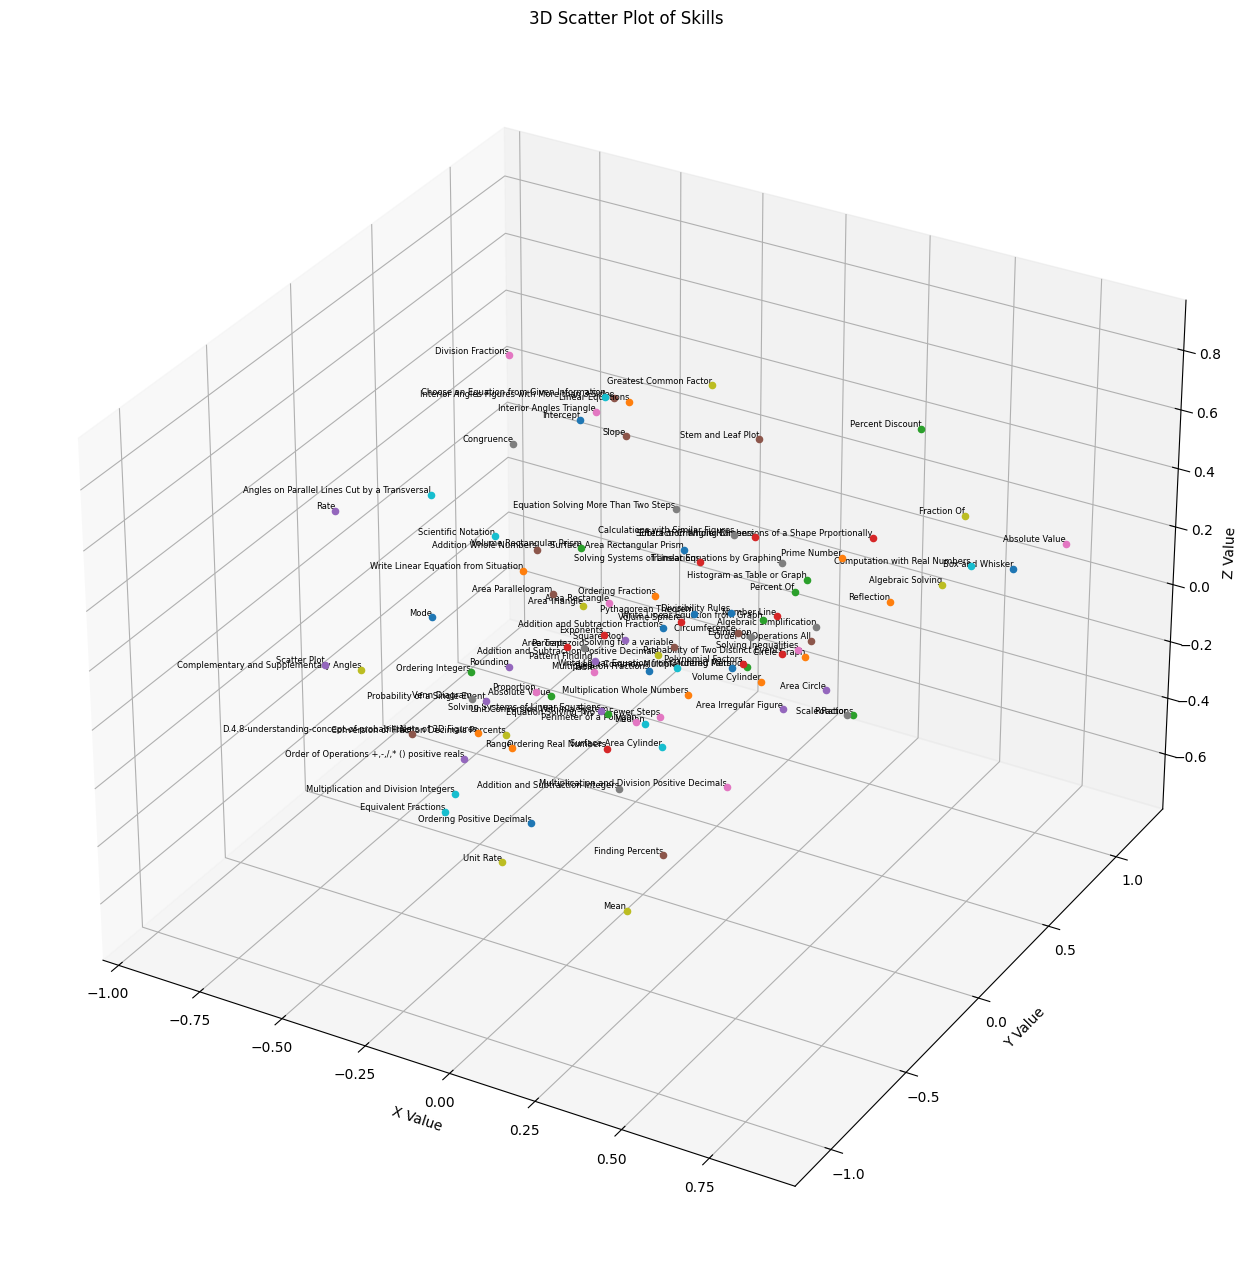

In [5]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
for i, row in df_embeddings.iterrows():
    ax.scatter(row['embedding_1'], row['embedding_2'], row['embedding_3'])  # 3D coordinates
    ax.text(row['embedding_1'], row['embedding_2'], row['embedding_3'], row['skill_name'], fontsize=6, ha='right', va='bottom')

ax.set_xlabel('X Value')
ax.set_ylabel('Y Value')
ax.set_zlabel('Z Value')
ax.set_title('3D Scatter Plot of Skills')

plt.show()


## 3.2) 2D Visualization

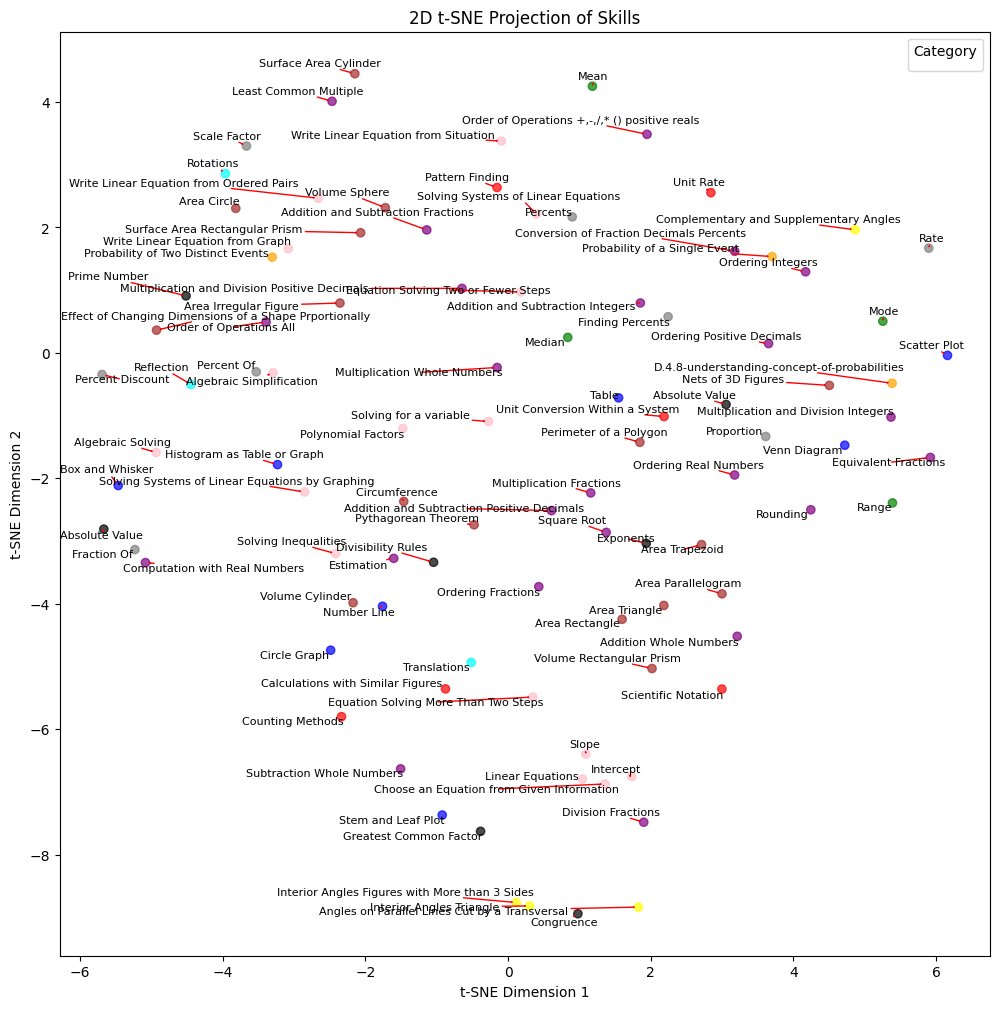

In [35]:
# Perform t-SNE to get 2D projections
tsne = TSNE(n_components=2, random_state=42)
df_embeddings[['tsne_1', 'tsne_2']] = tsne.fit_transform(df_embeddings[['embedding_1', 'embedding_2', 'embedding_3']])

# Set up color mapping based on the category column
category_colors = {category: color for category, color in zip(df_embeddings['category'].unique(), ['b', 'g', 'r', 'orange', 'yellow', 'black', 'brown', 'purple', 'grey', 'pink', 'cyan'])}
df_embeddings['color'] = df_embeddings['category'].map(category_colors)

# Plotting
plt.figure(figsize=(12, 12))

# Scatter plot, color by category
plt.scatter(df_embeddings['tsne_1'], df_embeddings['tsne_2'], c=df_embeddings['color'], alpha=0.7)

# Add text labels
texts = []
for i, row in df_embeddings.iterrows():
    texts.append(plt.text(row['tsne_1'], row['tsne_2'], row['skill_name'], fontsize=8, ha='right', va='bottom'))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Add labels and title
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('2D t-SNE Projection of Skills')

# Add legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, title="Category")

# Show plot
plt.show()


In [34]:
len(df_embeddings['category'].unique())

11

In [32]:
df_embeddings[df_embeddings['skill_name']=='Circle Graph']

,embedding_1,embedding_2,embedding_3,skill_name,category,tsne_1,tsne_2,color
skill_2,0.222455,0.589636,-0.1603,Circle Graph,Data Graphs,-2.486932,-4.740919,"(0.8941176470588236, 0.10196078431372549, 0.10..."


In [33]:
df_embeddings.head(15)

,embedding_1,embedding_2,embedding_3,skill_name,category,tsne_1,tsne_2,color
skill_1,0.826391,0.577524,0.347534,Box and Whisker,Data Graphs,-5.464528,-2.115762,"(0.8941176470588236, 0.10196078431372549, 0.10..."
skill_2,0.222455,0.589636,-0.160300,Circle Graph,Data Graphs,-2.486932,-4.740919,"(0.8941176470588236, 0.10196078431372549, 0.10..."
skill_3,0.342879,0.310721,0.270748,Histogram as Table or Graph,Data Graphs,-3.231874,-1.781415,"(0.8941176470588236, 0.10196078431372549, 0.10..."
skill_4,0.190475,0.462657,0.026876,Number Line,Data Graphs,-1.760256,-4.040544,"(0.8941176470588236, 0.10196078431372549, 0.10..."
skill_5,-0.871799,-0.199031,-0.194817,Scatter Plot,Data Graphs,6.158895,-0.040441,"(0.8941176470588236, 0.10196078431372549, 0.10..."
skill_6,-0.095838,0.989490,0.317313,Stem and Leaf Plot,Data Graphs,-0.923101,-7.369064,"(0.8941176470588236, 0.10196078431372549, 0.10..."
skill_7,-0.110000,-0.075436,-0.018596,Table,Data Graphs,1.548658,-0.717973,"(0.8941176470588236, 0.10196078431372549, 0.10..."
skill_8,-0.512454,-0.009398,-0.280904,Venn Diagram,Data Graphs,4.718899,-1.472878,"(0.8941176470588236, 0.10196078431372549, 0.10..."
skill_9,0.381036,-0.939872,-0.245416,Mean,Statistics,1.182053,4.250885,"(0.21568627450980393, 0.49411764705882355, 0.7..."
skill_10,0.077485,-0.157613,-0.095205,Median,Statistics,0.836050,0.246441,"(0.21568627450980393, 0.49411764705882355, 0.7..."


# 4) Clustering

## 4.1) Hierarchical Clustering

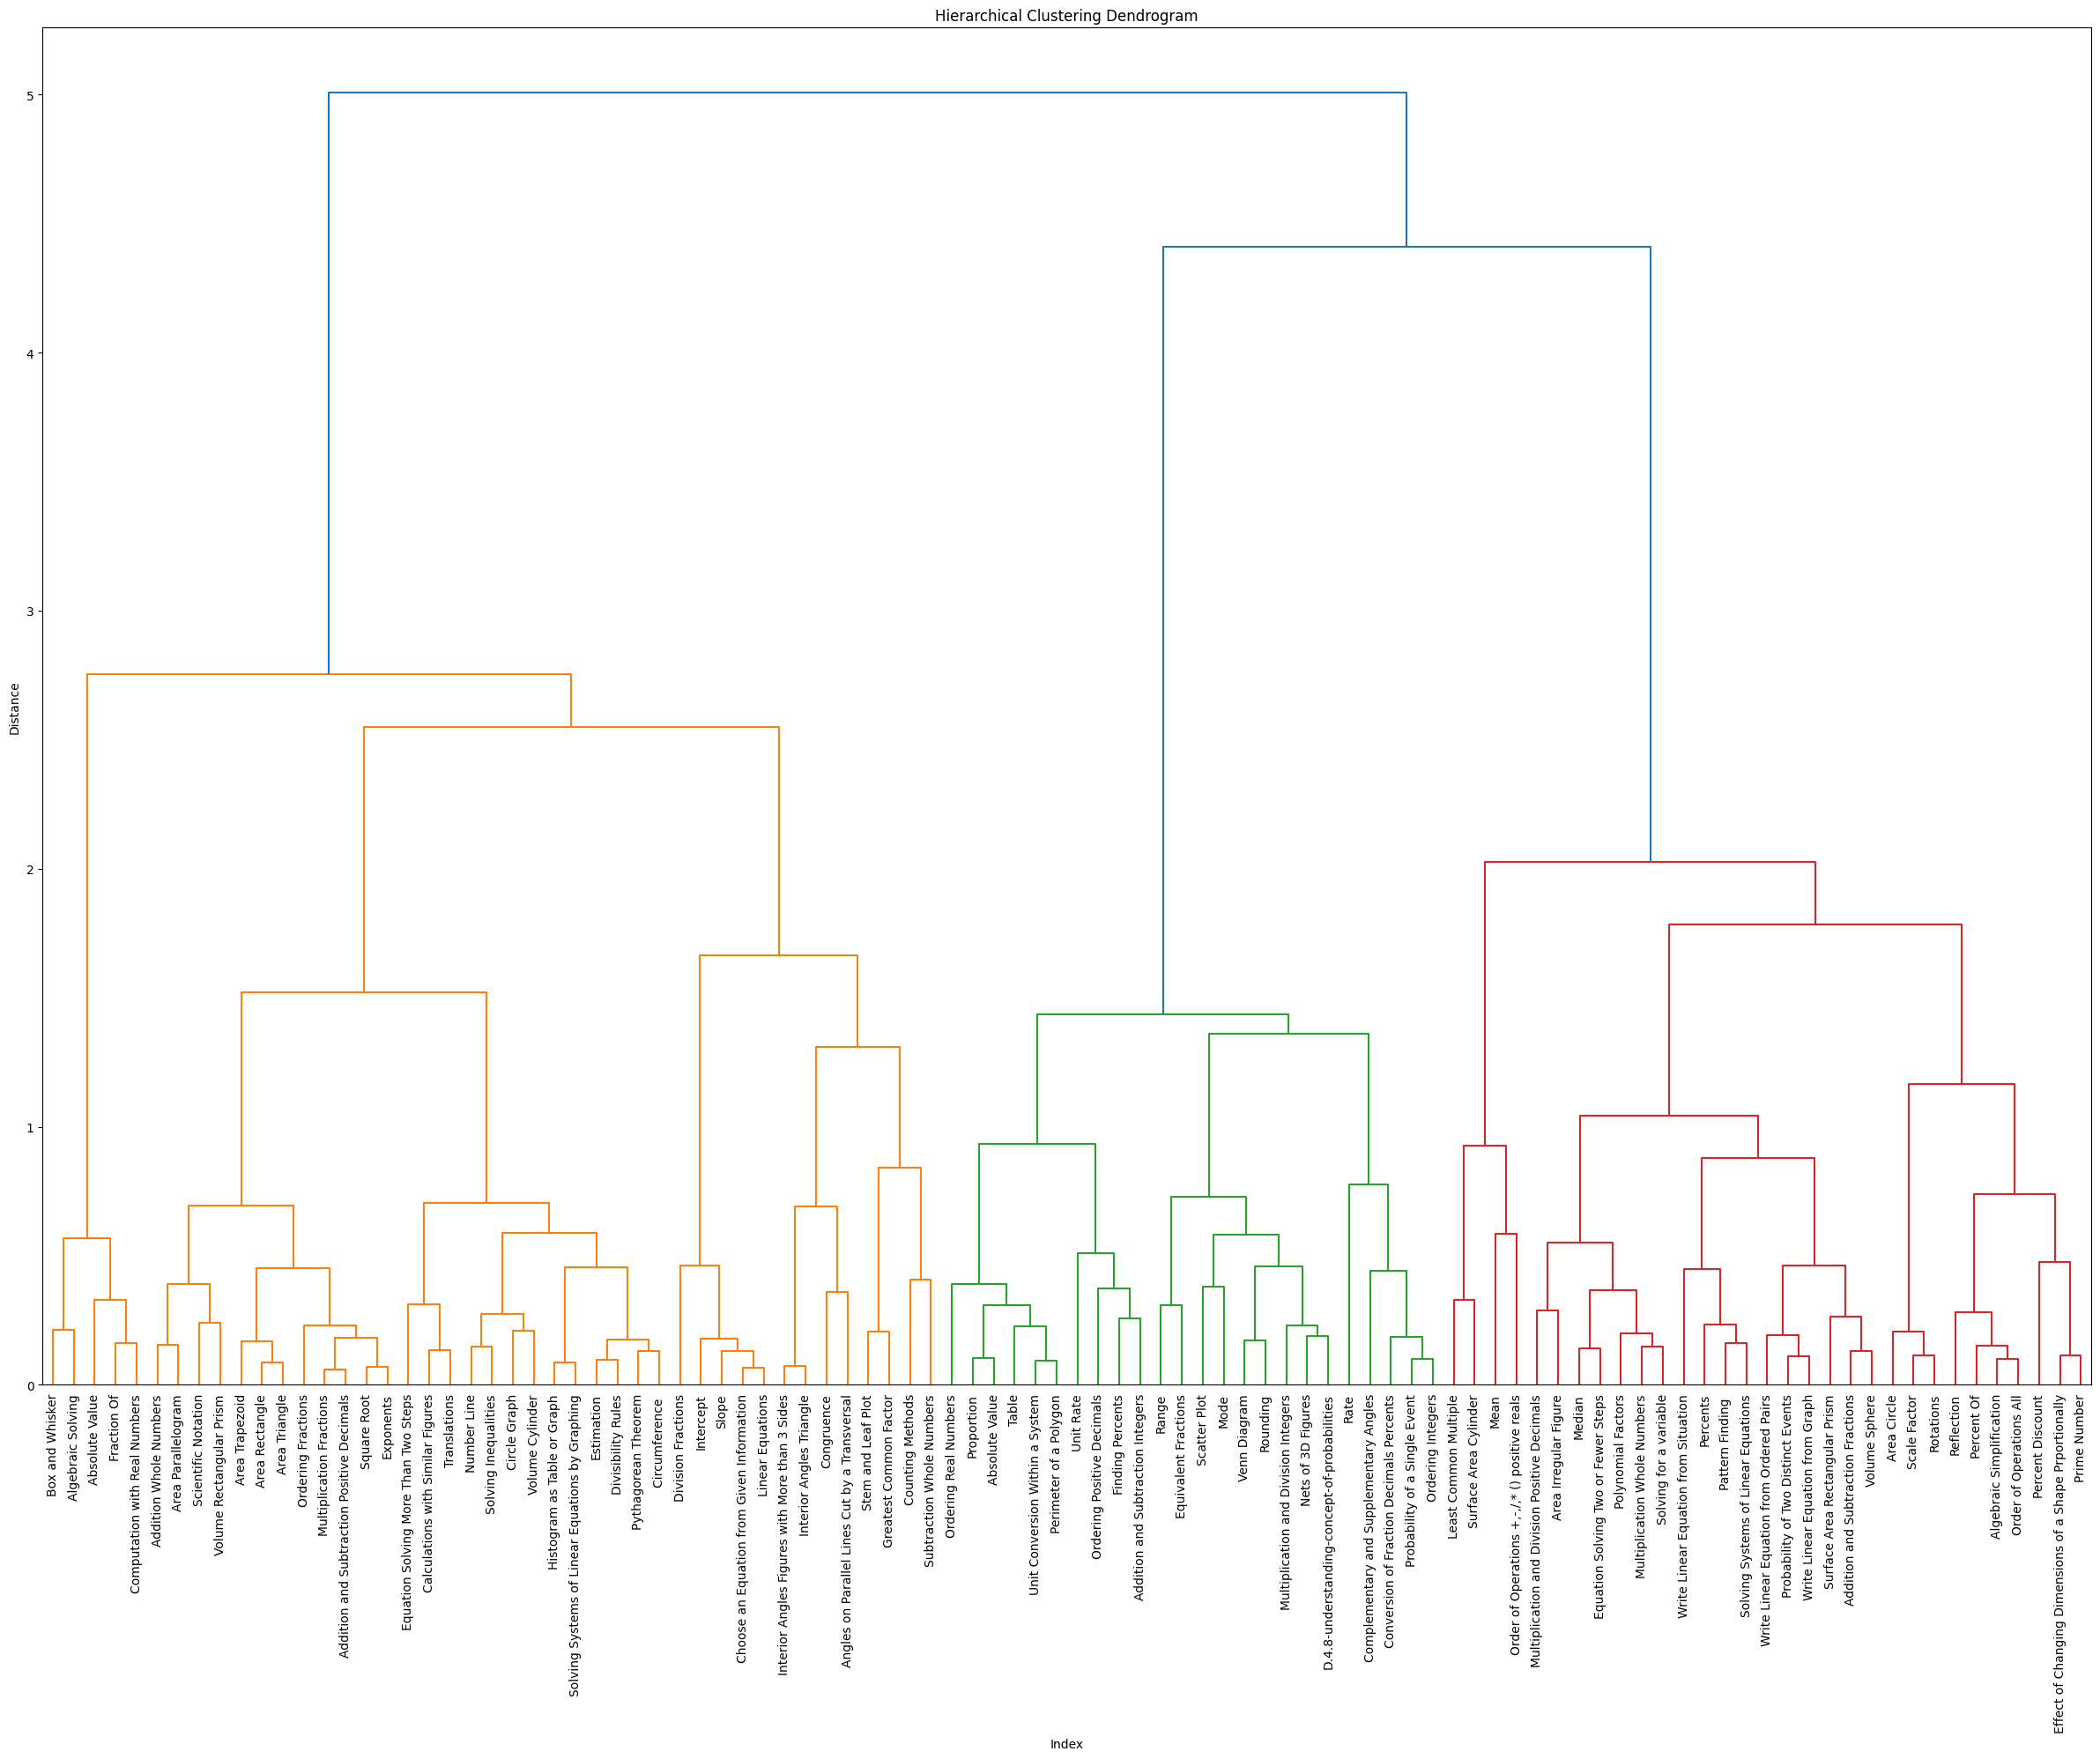

In [7]:
# Calculate the hierarchical matrix
linkage_matrix = sch.linkage(df_embeddings[['embedding_1', 'embedding_2', 'embedding_3']], method='ward')

plt.figure(figsize=(30, 20))
sch.dendrogram(linkage_matrix, labels=df_embeddings['skill_name'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()


## 4.2) K-Means Clustering

### 4.2.1) Elbow-method


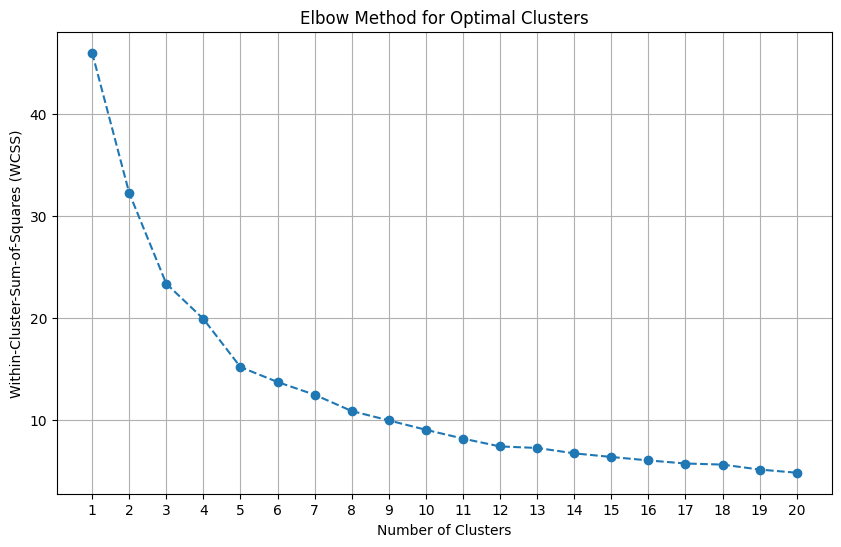

In [8]:
# Data preparation
data = df_embeddings[['embedding_1', 'embedding_2', 'embedding_3']]

wcss_list = []
range_n_clusters = range(1, 21)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(data)
    wcss_list.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, wcss_list, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster-Sum-of-Squares (WCSS)')
plt.xticks(range_n_clusters)
plt.grid()
plt.show()


The number of clusters should be 5.

In [9]:
n_clusters = 5

# KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_embeddings['cluster'] = kmeans.fit_predict(data)

for cluster in range(n_clusters):
    print(f"Cluster {cluster+1}:")
    skills = df_embeddings[df_embeddings['cluster'] == cluster]['skill_name'].tolist()
    print(", ".join(skills))
    print("-" * 400)



Cluster 1:
Stem and Leaf Plot, Interior Angles Figures with More than 3 Sides, Interior Angles Triangle, Congruence, Angles on Parallel Lines Cut by a Transversal, Division Fractions, Subtraction Whole Numbers, Scientific Notation, Choose an Equation from Given Information, Intercept, Linear Equations, Slope, Greatest Common Factor
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Cluster 2:
Box and Whisker, Histogram as Table or Graph, Effect of Changing Dimensions of a Shape Prportionally, Fraction Of, Percent Of, Prime Number, Absolute Value, Algebraic Simplification, Algebraic Solving, Percent Discount, Reflection, Order of Operations Al